In [13]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CHARGEMENT DES DONNÉES
# ==========================================

# Chargement du tableau principal (avec les patients et les scores d'IgE)
# On spécifie le séparateur ';' propre à votre fichier
df_principal = pd.read_csv("../data/allergenchipchallenge-data-corrected-final-hdh-sfa (2).csv", sep=";")

# Chargement du dictionnaire
df_dict = pd.read_csv("../data/acc_dictionnaire_final.csv", sep=";",encoding = 'utf-8')  # Assurez-vous que ce fichier contient les colonnes nécessaires pour le mapping")


# ==========================================
# 2. CRÉATION DU MAPPING (ACRONYME -> CATÉGORIE)
# ==========================================

# /!\ ÉTAPE À ADAPTER SELON VOTRE DICTIONNAIRE /!\
# Ici, nous créons manuellement un dictionnaire de correspondance basé sur les standards ISAC.
# Si votre fichier 'df_dict' contient déjà ces colonnes, on pourra automatiser cette partie.
mapping_categories = {
    # POLLENS D'ARBRES
    'Aln_g_1': 'Pollens', 'Bet_v_1': 'Pollens', 'Bet_v_2': 'Pollens', 'Bet_v_4': 'Pollens',
    'Cup_a_1': 'Pollens', 'Ole_e_1': 'Pollens', 'Ole_e_7': 'Pollens', 'Ole_e_9': 'Pollens',
    'Cor_a_1.0101': 'Pollens', 'Cor_a_1.0401': 'Pollens',
    
    # GRAMINÉES ET HERBACÉES
    'Amb_a_1': 'Pollens', 'Art_v_1': 'Pollens', 'Art_v_3': 'Pollens',
    'Phl_p_1': 'Pollens', 'Phl_p_2': 'Pollens', 'Phl_p_4': 'Pollens', 'Phl_p_5': 'Pollens',
    'Phl_p_6': 'Pollens', 'Phl_p_7': 'Pollens', 'Phl_p_11': 'Pollens', 'Phl_p_12': 'Pollens',
    'Che_a_1': 'Pollens', 'Par_j_2': 'Pollens',

    # ALIMENTS (Fruits, Légumes, Graines)
    'Act_d_1': 'Aliments', 'Act_d_2': 'Aliments', 'Act_d_5': 'Aliments', 'Act_d_8': 'Aliments',
    'Ana_o_2': 'Aliments', 'Api_g_1': 'Aliments', 
    'Ara_h_1': 'Aliments', 'Ara_h_2': 'Aliments', 'Ara_h_3': 'Aliments', 'Ara_h_6': 'Aliments', 'Ara_h_8': 'Aliments', 'Ara_h_9': 'Aliments',
    'Ber_e_1': 'Aliments', 'Cor_a_8': 'Aliments', 'Cor_a_9': 'Aliments', 'Cor_a_14': 'Aliments',
    'Gly_m_4': 'Aliments', 'Gly_m_5': 'Aliments', 'Gly_m_6': 'Aliments',
    'Mal_d_1': 'Aliments', 'Pru_p_3': 'Aliments', 'Ses_i_1': 'Aliments', 'Sin_a_1': 'Aliments',
    
    # PRODUITS ANIMAUX (Lait, Œuf, Viande, Poisson)
    'Bos_d_4': 'Aliments', 'Bos_d_5': 'Aliments', 'Bos_d_6': 'Aliments', 'Bos_d_8': 'Aliments', 'Bos_d_Lactoferrin': 'Aliments',
    'Gal_d_1': 'Aliments', 'Gal_d_2': 'Aliments', 'Gal_d_3': 'Aliments', 'Gal_d_5': 'Aliments',
    'Gad_m_1': 'Aliments', 'Pen_m_1': 'Aliments', 'Pen_m_2': 'Aliments', 'Pen_m_4': 'Aliments',
    
    # ANIMAUX DOMESTIQUES
    'Can_f_1': 'Animaux', 'Can_f_2': 'Animaux', 'Can_f_3': 'Animaux', 'Can_f_5': 'Animaux', 'Can_f_6': 'Animaux',
    'Fel_d_1': 'Animaux', 'Fel_d_2': 'Animaux', 'Fel_d_4': 'Animaux', 'Fel_d_7': 'Animaux',
    'Equ_c_1': 'Animaux', 'Mus_m_1': 'Animaux',

    # ACARIENS ET BLATTES
    'Der_f_1': 'Acariens/Blattes', 'Der_f_2': 'Acariens/Blattes',
    'Der_p_1': 'Acariens/Blattes', 'Der_p_2': 'Acariens/Blattes', 'Der_p_10': 'Acariens/Blattes',
    'Bla_g_1': 'Acariens/Blattes', 'Bla_g_2': 'Acariens/Blattes', 'Bla_g_5': 'Acariens/Blattes', 'Bla_g_7': 'Acariens/Blattes',
    'Blo_t_5': 'Acariens/Blattes', 'Lep_d_2': 'Acariens/Blattes',

    # MOISISSURES, VENINS ET LATEX
    'Alt_a_1': 'Moisissures/Autres', 'Alt_a_6': 'Moisissures/Autres',
    'Asp_f_1': 'Moisissures/Autres', 'Asp_f_3': 'Moisissures/Autres', 'Asp_f_6': 'Moisissures/Autres',
    'Cla_h_8': 'Moisissures/Autres', 'Pen_c_3': 'Moisissures/Autres',
    'Api_m_1': 'Moisissures/Autres', 'Api_m_4': 'Moisissures/Autres',
    'Vesp_v_1': 'Moisissures/Autres', 'Vesp_v_5': 'Moisissures/Autres',
    'Hev_b_1': 'Moisissures/Autres', 'Hev_b_3': 'Moisissures/Autres', 'Hev_b_5': 'Moisissures/Autres', 'Hev_b_6.02': 'Moisissures/Autres',
    'Ani_s_1': 'Moisissures/Autres', 'Ani_s_3': 'Moisissures/Autres',
    'Hom_s_LF': 'Moisissures/Autres'
}


# ==========================================
# 3. NETTOYAGE ET CONVERSION DES DONNÉES
# ==========================================

# Identification des colonnes de métadonnées des patients (à ne pas sommer)
colonnes_metadonnees = [
    'Patient_ID', 'Chip_Type', 'Age', 'Gender', 'Blood_Month_sample',
    'French_Residence_Department', 'French_Region', 'Rural_or_urban_area',
    'Sensitization', 'Treatment_of_rhinitis', 'Treatment_of_athsma',
    'Age_of_onsets', 'Skin_Symptoms', 'General_cofactors', 'Treatment_of_atopic_dematitis'
]

# Sélectionner uniquement les colonnes d'allergènes présentes dans le fichier principal
colonnes_allergenes_presentes = [col for col in df_principal.columns if col in mapping_categories]

# Création d'une copie propre pour travailler
df_clean = df_principal.copy()

# Conversion des virgules en points pour toutes les colonnes d'allergènes (ex: "7,38" -> 7.38)
for col in colonnes_allergenes_presentes:
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.', regex=False)
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0.0)


# ==========================================
# 4. AGRÉGATION PAR CATÉGORIE
# ==========================================

# Extraction des métadonnées des patients
df_final = df_clean[colonnes_metadonnees].copy()

# Groupement horizontal (axis=1) des allergènes par leur catégorie en calculant la SOMME
# (Vous pouvez remplacer .sum() par .max() si vous voulez le score maximal de la catégorie)
df_categories_somme = df_clean[colonnes_allergenes_presentes].groupby(mapping_categories, axis=1).sum()

# Fusion des métadonnées et des scores par grandes catégories
df_resultat_complet = pd.concat([df_final, df_categories_somme], axis=1)


# ==========================================
# 5. AFFICHAGE ET EXPORT
# ==========================================

# Affichage des 5 premières lignes dans le notebook pour vérification
print("Aperçu du nouveau tableau regroupé par catégories :")
display(df_resultat_complet.head())

# Sauvegarde du nouveau tableau dans un fichier CSV bien propre
df_resultat_complet.to_csv("allergenes_regroupes_par_categories.csv", sep=";", index=False)
print("\nLe fichier 'allergenes_regroupes_par_categories.csv' a été créé avec succès !")

/tmp/ipykernel_51920/3397998123.py:10: DtypeWarning: Columns (9,10,11,13,14,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255) have mixed types. Specify dtype option on import or set low_memory=False.
  df_principal = pd.read_csv("../data/allergenchipchallenge-data-corrected-final-hdh-sfa (2).csv", sep=";")
/tmp/ipykernel_51920/3397998123.py:104: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_categories_somme = df_clean[colonnes_allergenes_presentes].groupby(mappi

Aperçu du nouveau tableau regroupé par catégories :


,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_athsma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,9,9,9,9,0,9,0.43,0.00,0.00,0.0,0.00
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,77.91,0.00,0.0,168.54
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2,9,0,9,5,9,0.00,0.00,0.00,0.0,0.00
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,34.68,20.77,0.72,0.0,268.78
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,0.00,0.00,0.0,140.05



Le fichier 'allergenes_regroupes_par_categories.csv' a été créé avec succès !


In [17]:
# Affiche les 50 premières lignes
display(df_resultat_complet.head(50))

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_athsma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,9,9,9,9,0,9,0.43,0.00,0.00,0.00,0.00
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,77.91,0.00,0.00,168.54
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2,9,0,9,5,9,0.00,0.00,0.00,0.00,0.00
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,34.68,20.77,0.72,0.00,268.78
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,0.00,0.00,0.00,140.05
5,FHB0006,ISAC_V1,50.0,1.0,1.0,deptY,regionB,9,0,9,9,9,9,0,9,0.00,0.00,0.00,0.00,0.00
6,FHB0007,ISAC_V1,61.0,0.0,1.0,deptY,regionB,9,0,9,9,0,1,0,9,0.00,0.00,0.00,0.00,0.00
7,FHB0008,ISAC_V1,39.0,0.0,1.0,deptY,regionB,9,0,9,9,9,9,0,9,0.00,0.00,0.00,0.00,0.00
8,FHB0009,ISAC_V1,68.0,0.0,2.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,0.00,2.96,0.00,0.00
9,FHB0010,ISAC_V1,51.0,0.0,2.0,deptY,regionB,9,0,9,9,6,9,0,9,0.00,0.00,0.00,0.00,0.00


In [18]:
print(df_resultat_complet.shape)
# Résultat affiché : (nombre_de_patients, nombre_de_colonnes)

(4271, 20)


In [19]:
display(df_resultat_complet.head(4271))

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_athsma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,21.0,1.0,11.0,deptY,regionB,9,1,9,9,9,9,0,9,0.43,0.00,0.00,0.00,0.00
1,FHB0002,ISAC_V1,45.0,0.0,12.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,77.91,0.00,0.00,168.54
2,FHB0003,ISAC_V1,18.0,1.0,1.0,deptY,regionB,9,0,2,9,0,9,5,9,0.00,0.00,0.00,0.00,0.00
3,FHB0004,ISAC_V1,19.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,34.68,20.77,0.72,0.00,268.78
4,FHB0005,ISAC_V1,28.0,0.0,1.0,deptY,regionB,9,1,9,9,9,9,0,9,0.00,0.00,0.00,0.00,140.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,XPW0509,ISAC_V1,45.0,0.0,6.0,deptA,regionA,9,1,9,9,9,9,0,9,11.62,0.39,0.21,2.66,21.74
4267,XPW0510,ISAC_V1,44.0,0.0,6.0,deptA,regionA,9,1,9,9,9,9,0,9,13.11,0.00,0.00,0.00,0.22
4268,XPW0511,ISAC_V1,23.0,1.0,6.0,deptA,regionA,9,1,9,9,9,9,0,9,0.00,7.38,1.40,14.14,92.69
4269,XPW0512,ISAC_V1,29.0,0.0,6.0,deptA,regionA,9,1,9,9,9,9,0,9,0.00,24.37,0.00,0.00,52.06


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

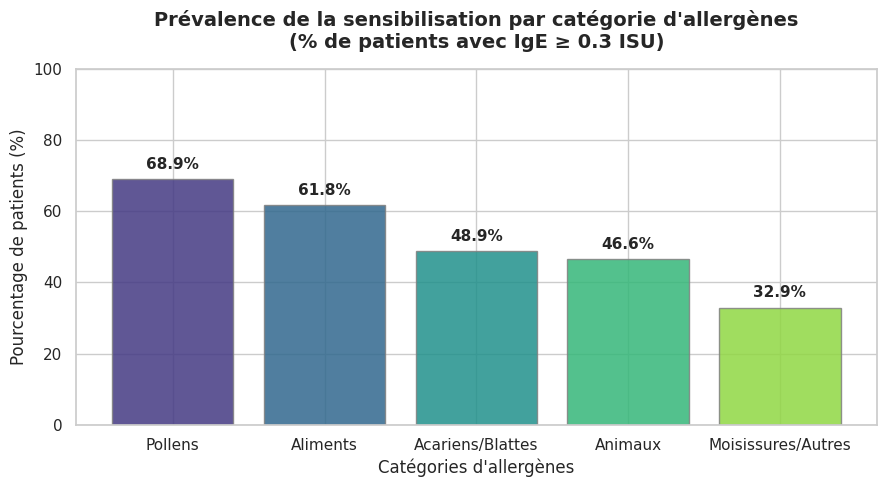

In [ ]:
# --- Graphique 1 : Taux de Prévalence ---

df_scores_categories = df_resultat_complet.drop(columns=colonnes_metadonnees)
seuil_positif = 0.3
prevalence = (df_scores_categories >= seuil_positif).mean() * 100
prevalence = prevalence.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", len(prevalence))
bars = plt.bar(prevalence.index, prevalence.values, color=colors, edgecolor='grey', alpha=0.85)

# Habillage du graphique
plt.title("Prévalence de la sensibilisation par catégorie d'allergènes\n(% de patients avec IgE ≥ 0.3 ISU)", pad=15, fontweight='bold')
plt.ylabel("Pourcentage de patients (%)")
plt.xlabel("Catégories d'allergènes")
plt.ylim(0, 100)

# Ajout des étiquettes de valeurs sur chaque barre
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show() # Affiche le graphique directement dans votre Notebook VS Code

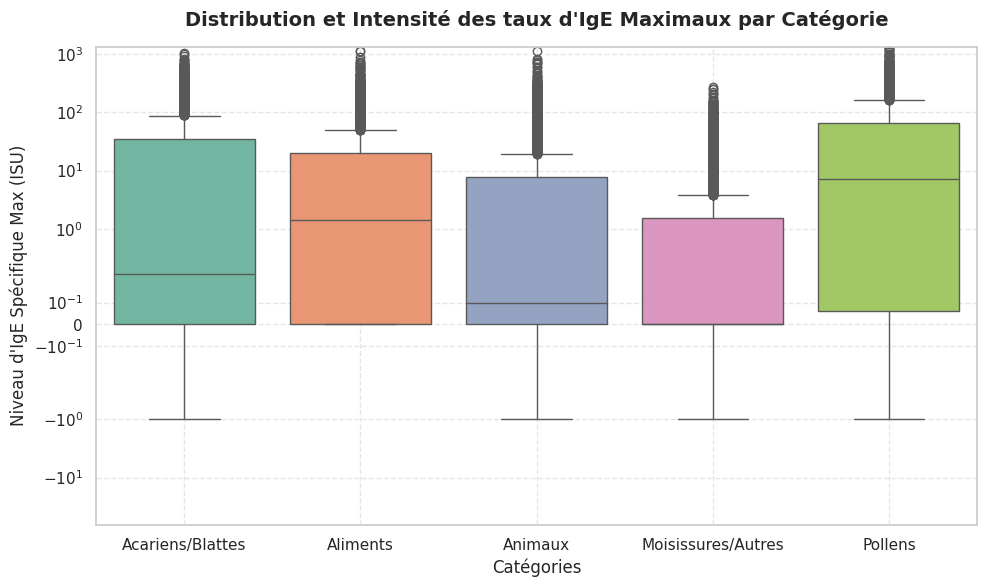

In [ ]:
# --- Graphique 2 : Distribution des taux d'IgE ---

plt.figure(figsize=(10, 6))
df_long = df_scores_categories.melt(var_name="Catégorie", value_name="IgE Max (ISU)")
sns.boxplot(x="Catégorie", y="IgE Max (ISU)", data=df_long, palette="Set2", hue="Catégorie")

plt.title("Distribution et Intensité des taux d'IgE Maximaux par Catégorie", pad=15, fontweight='bold')
plt.ylabel("Niveau d'IgE Spécifique Max (ISU)")
plt.xlabel("Catégories")
plt.yscale('symlog', linthresh=0.3)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================================
# 1. CHARGEMENT ET NETTOYAGE AUTOMATIQUE DES DONNÉES
# ====================================================================
# Chargement de votre fichier principal (vérifiez bien que le nom correspond)
df_principal = pd.read_csv("allergenchipchallenge-data-corrected-final-hdh-sfa (2).csv", sep=";")

# Définition exacte du dictionnaire de correspondance (Mapping)
mapping_categories = {
    # 1. POLLENS D'ARBRES (Tree Pollens)
    'Aln_g_1': 'Tree_Pollens', 'Bet_v_1': 'Tree_Pollens', 'Bet_v_2': 'Tree_Pollens', 'Bet_v_4': 'Tree_Pollens',
    'Cup_a_1': 'Tree_Pollens', 'Ole_e_1': 'Tree_Pollens', 'Ole_e_7': 'Tree_Pollens', 'Ole_e_9': 'Tree_Pollens',
    'Cor_a_1.0101': 'Tree_Pollens', 'Cor_a_1.0401': 'Tree_Pollens',
    
    # 2. POLLENS DE GRAMINÉES (Grass Pollens)
    'Phl_p_1': 'Grass_Pollens', 'Phl_p_2': 'Grass_Pollens', 'Phl_p_4': 'Grass_Pollens', 'Phl_p_5': 'Grass_Pollens',
    'Phl_p_6': 'Grass_Pollens', 'Phl_p_7': 'Grass_Pollens', 'Phl_p_11': 'Grass_Pollens', 'Phl_p_12': 'Grass_Pollens',
    
    # 3. POLLENS D'HERBACÉES (Herbaceous Pollens)
    'Amb_a_1': 'Herbaceous_Pollens', 'Art_v_1': 'Herbaceous_Pollens', 'Art_v_3': 'Herbaceous_Pollens',
    'Che_a_1': 'Herbaceous_Pollens', 'Par_j_2': 'Herbaceous_Pollens',

    # 4. SQUAMES D'ANIMAUX (Animal Dander)
    'Can_f_1': 'Animal_Dander', 'Can_f_2': 'Animal_Dander', 'Can_f_3': 'Animal_Dander', 'Can_f_5': 'Animal_Dander', 'Can_f_6': 'Animal_Dander',
    'Fel_d_1': 'Animal_Dander', 'Fel_d_2': 'Animal_Dander', 'Fel_d_4': 'Animal_Dander', 'Fel_d_7': 'Animal_Dander',
    'Equ_c_1': 'Animal_Dander', 'Mus_m_1': 'Animal_Dander',

    # 5. ACARIENS ET BLATTES (Mite & Cockroach)
    'Der_f_1': 'Mite_Cockroach', 'Der_f_2': 'Mite_Cockroach',
    'Der_p_1': 'Mite_Cockroach', 'Der_p_2': 'Mite_Cockroach', 'Der_p_10': 'Mite_Cockroach',
    'Bla_g_1': 'Mite_Cockroach', 'Bla_g_2': 'Mite_Cockroach', 'Bla_g_5': 'Mite_Cockroach', 'Bla_g_7': 'Mite_Cockroach',
    'Blo_t_5': 'Mite_Cockroach', 'Lep_d_2': 'Mite_Cockroach',

    # 6. MOISISSURES ET LEVURES (Molds & Yeast)
    'Alt_a_1': 'Molds_Yeast', 'Alt_a_6': 'Molds_Yeast',
    'Asp_f_1': 'Molds_Yeast', 'Asp_f_3': 'Molds_Yeast', 'Asp_f_6': 'Molds_Yeast',
    'Cla_h_8': 'Molds_Yeast', 'Pen_c_3': 'Molds_Yeast'
}

# Identification et conversion des colonnes numériques (Virgules d'origine en Points de calcul)
colonnes_allergenes_presentes = [col for col in df_principal.columns if col in mapping_categories]
df_clean = df_principal.copy()

for col in colonnes_allergenes_presentes:
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.', regex=False)
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0.0)

# ====================================================================
# 2. CALCUL ET AGRÉGATION DES SCORES (Création sécurisée de la variable)
# ====================================================================
df_scores_categories = df_clean[colonnes_allergenes_presentes].groupby(mapping_categories, axis=1).max()

# ====================================================================
# 3. GÉNÉRATION DES GRAPHICKS DE VISUALISATION
# ====================================================================
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# --- Graphique 1 : Taux de Prévalence ---
seuil_positif = 0.3
prevalence = (df_scores_categories >= seuil_positif).mean() * 100
prevalence = prevalence.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", len(prevalence))
bars = plt.bar(prevalence.index, prevalence.values, color=colors, edgecolor='grey', alpha=0.85)

plt.title("Prévalence de la sensibilisation par catégorie d'allergènes\n(% de patients avec IgE ≥ 0.3 ISU)", pad=15, fontweight='bold')
plt.ylabel("Pourcentage de patients (%)")
plt.xlabel("Catégories d'allergènes")
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Graphique 2 : Distribution des taux d'IgE ---
plt.figure(figsize=(10, 6))
df_long = df_scores_categories.melt(var_name="Catégorie", value_name="IgE Max (ISU)")
sns.boxplot(x="Catégorie", y="IgE Max (ISU)", data=df_long, palette="Set2", hue="Catégorie")

plt.title("Distribution et Intensité des taux d'IgE Maximaux par Catégorie", pad=15, fontweight='bold')
plt.ylabel("Niveau d'IgE Spécifique Max (ISU)")
plt.xlabel("Catégories")
plt.yscale('symlog', linthresh=0.3)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pandas
import numpy as np

In [2]:
import os
import sys
import logging
import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime
from pathlib import Path

In [3]:
base_url_allergies = "https://tabular-api.data.gouv.fr/api"
id_data_allergies = "7b55f69c-1773-4b98-9767-2301f71ff350"
url_allergies = base_url_allergies + "/resources/" + id_data_allergies + "/data/csv/"
allergies_filepath = "../data/allergies.csv"

In [4]:
df = pd.read_csv(url_allergies, sep=";") 

In [ ]:
# Téléchargement du fichier CSV depuis l'URL et sauvegarde locale
# tableau principal avec les patients et les scores d'IgE

response = requests.get(url_allergies)
if response.status_code == 200:
    with open(allergies_filepath, 'wb') as f:
        f.write(response.content)
    print(f"Fichier téléchargé et sauvegardé sous {allergies_filepath}")
else:
    print(f"Erreur lors du téléchargement du fichier : {response.status_code}") 
df = pd.read_csv(url_allergies, sep=";") 

Fichier téléchargé et sauvegardé sous ../data/allergies.csv


In [18]:
show_df = df.head()
print(show_df) 

  __id,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,French_Residence_Department,French_Region,Rural_or_urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_athsma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Act_d_1,Act_d_2,Act_d_5,Act_d_8,Aln_g_1,Alt_a_1,Alt_a_6,Amb_a_1,Ana_o_2,Ani_s_1,Ani_s_3,Api_g_1,Api_m_1,Api_m_4,Ara_h_1,Ara_h_2,Ara_h_3,Ara_h_6,Ara_h_8,Ara_h_9,Art_v_1,Art_v_3,Asp_f_1,Asp_f_3,Asp_f_6,Ber_e_1,Bet_v_1,Bet_v_2,Bet_v_4,Bla_g_1,Bla_g_2,Bla_g_5,Bla_g_7,Blo_t_5,Bos_d_4,Bos_d_5,Bos_d_6,Bos_d_8,Bos_d_Lactoferrin,Can_f_1,Can_f_2,Can_f_3,Can_f_5,Che_a_1,Cla_h_8,Cor_a_1.0101,Cor_a_1.0401,Cor_a_8,Cor_a_9,Cry_j_1,Cup_a_1,Cyn_d_1,Der_f_1,Der_f_2,Der_p_1,Der_p_10,Der_p_2,Equ_c_1,Equ_c_3,Fag_e_2,Fel_d_1,Fel_d_2,Fel_d_4,Gad_c_1,Gal_d_1,Gal_d_2,Gal_d_3,Gal_d_5,Gly_m_4,Gly_m_5,Gly_m_6,Hev_b_1,Hev_b_3,Hev_b_5,Hev_b_6.01,Hev_b_8,Jug_r_1,Jug_r_2,Jug_r_3,Lep_d_2,Mal_d_1,Mer_a_1,Mus_m_1,MUXF3,Ole_e_1,Ole_e_7,Ole_e_9,Par_j_2,Pen_m_1,Pen_m_2,Pen_m_

In [ ]:
# Chargement du dictionnaire

In [33]:
base_url_dictionnaire = "https://www.data.gouv.fr/datasets/allergen-chip-challenge?resource_id=878dd36c-2ede-4a69-9a7a-4de36d27333f"

id_data_dictionnaire = "878dd36c-2ede-4a69-9a7a-4de36d27333f"

url_dictionnaire = base_url_dictionnaire + "/resources/" + id_data_dictionnaire + "/data/csv/"

dictionnaire_filepath = "../data/dictionnaire.csv"

In [34]:
#  sauvegarde du dictionnaire  

import pandas as pd

# URL du fichier CSV
url_dictionnaire = "https://www.data.gouv.fr/fr/datasets/r/878dd36c-2ede-4a69-9a7a-4de36d27333f"


In [ ]:
# Charger le CSV
df = pd.read_csv(url_dictionnaire)

# Sauvegarder dans le notebook
dictionnaire_filepath = "dictionnaire.csv"
df.to_csv(dictionnaire_filepath, index=False)

print("Fichier sauvegardé :", dictionnaire_filepath)

# Afficher les premières lignes
df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 11: invalid continuation byte

In [ ]:
# Chargement du dictionnaire
df_dict = pd.read_csv("acc-dictionnaire-final (1).xls - Feuil1.csv")

In [ ]:
# 2. DICTIONNAIRE DE MAPPING DES ACRONYMES
# ==========================================
# Correspondance officielle entre les protéines (puces ISAC) et vos catégories cibles
mapping_categories = {
    # 1. POLLENS D'ARBRES (Tree Pollens)
    'Aln_g_1': 'Tree_Pollens', 'Bet_v_1': 'Tree_Pollens', 'Bet_v_2': 'Tree_Pollens', 'Bet_v_4': 'Tree_Pollens',
    'Cup_a_1': 'Tree_Pollens', 'Ole_e_1': 'Tree_Pollens', 'Ole_e_7': 'Tree_Pollens', 'Ole_e_9': 'Tree_Pollens',
    'Cor_a_1.0101': 'Tree_Pollens', 'Cor_a_1.0401': 'Tree_Pollens',
    
    # 2. POLLENS DE GRAMINÉES (Grass Pollens)
    'Phl_p_1': 'Grass_Pollens', 'Phl_p_2': 'Grass_Pollens', 'Phl_p_4': 'Grass_Pollens', 'Phl_p_5': 'Grass_Pollens',
    'Phl_p_6': 'Grass_Pollens', 'Phl_p_7': 'Grass_Pollens', 'Phl_p_11': 'Grass_Pollens', 'Phl_p_12': 'Grass_Pollens',
    
    # 3. POLLENS D'HERBACÉES (Herbaceous Pollens)
    'Amb_a_1': 'Herbaceous_Pollens', 'Art_v_1': 'Herbaceous_Pollens', 'Art_v_3': 'Herbaceous_Pollens',
    'Che_a_1': 'Herbaceous_Pollens', 'Par_j_2': 'Herbaceous_Pollens',

    # 4. SQUAMES D'ANIMAUX (Animal Dander)
    'Can_f_1': 'Animal_Dander', 'Can_f_2': 'Animal_Dander', 'Can_f_3': 'Animal_Dander', 'Can_f_5': 'Animal_Dander', 'Can_f_6': 'Animal_Dander',
    'Fel_d_1': 'Animal_Dander', 'Fel_d_2': 'Animal_Dander', 'Fel_d_4': 'Animal_Dander', 'Fel_d_7': 'Animal_Dander',
    'Equ_c_1': 'Animal_Dander', 'Mus_m_1': 'Animal_Dander',

    # 5. ACARIENS ET BLATTES (Mite & Cockroach)
    'Der_f_1': 'Mite_Cockroach', 'Der_f_2': 'Mite_Cockroach',
    'Der_p_1': 'Mite_Cockroach', 'Der_p_2': 'Mite_Cockroach', 'Der_p_10': 'Mite_Cockroach',
    'Bla_g_1': 'Mite_Cockroach', 'Bla_g_2': 'Mite_Cockroach', 'Bla_g_5': 'Mite_Cockroach', 'Bla_g_7': 'Mite_Cockroach',
    'Blo_t_5': 'Mite_Cockroach', 'Lep_d_2': 'Mite_Cockroach',

    # 6. MOISISSURES ET LEVURES (Molds & Yeast)
    'Alt_a_1': 'Molds_Yeast', 'Alt_a_6': 'Molds_Yeast',
    'Asp_f_1': 'Molds_Yeast', 'Asp_f_3': 'Molds_Yeast', 'Asp_f_6': 'Molds_Yeast',
    'Cla_h_8': 'Molds_Yeast', 'Pen_c_3': 'Molds_Yeast'
}

